## Discretization

### Histogram of Discretized Attribute

Displaying histograms of new binned attributes...


/var/folders/4z/9ddz1dxn051gf97hvy69q3f80000gn/T/ipykernel_21060/850101618.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], data=df, x='lat_bin', palette='viridis')
/var/folders/4z/9ddz1dxn051gf97hvy69q3f80000gn/T/ipykernel_21060/850101618.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], data=df, x='lon_bin', palette='plasma')


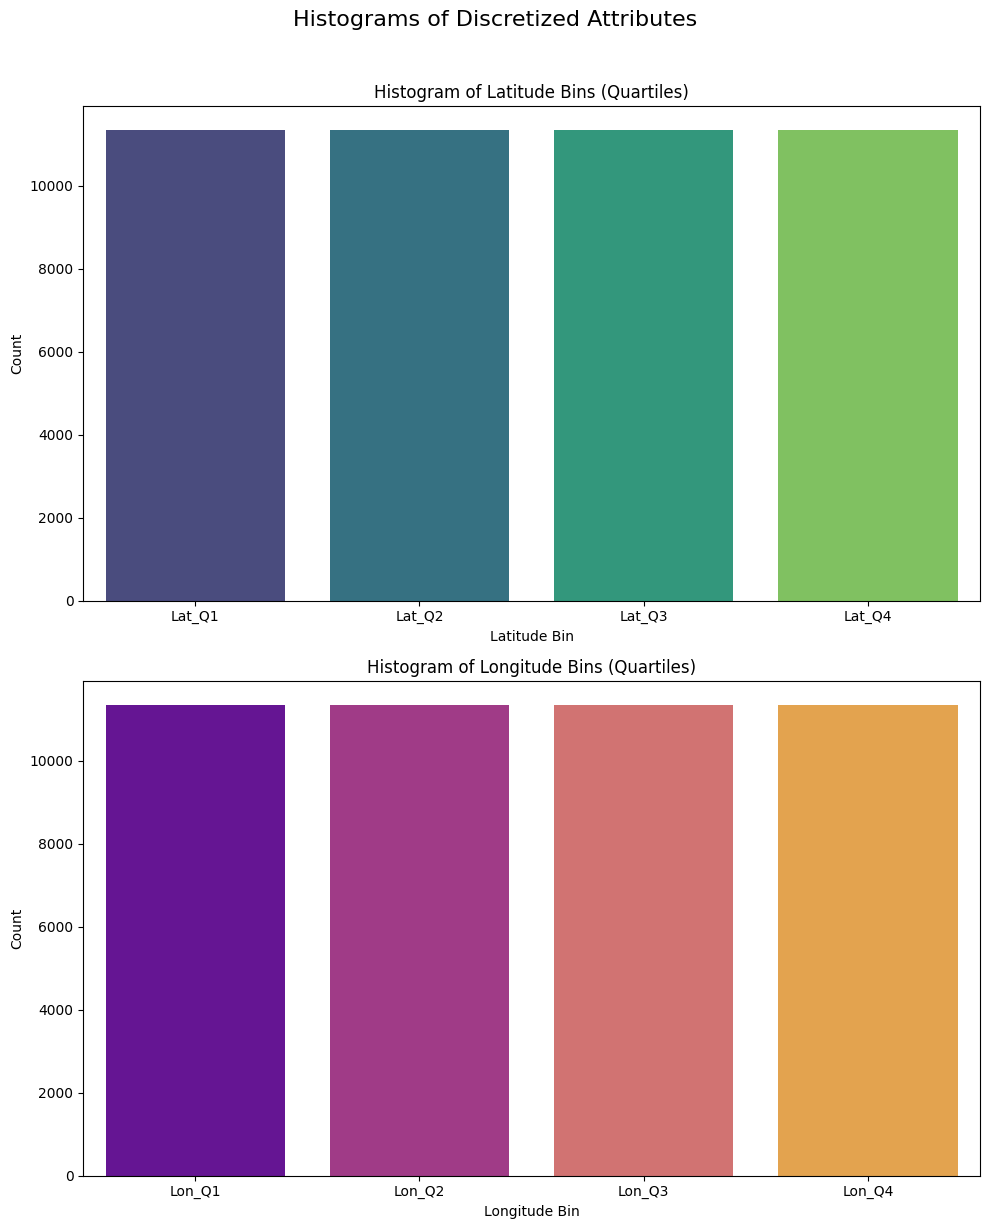

In [5]:
# Discretization
df['lat_bin'] = pd.qcut(df['latitude'], q=4, labels=['Lat_Q1', 'Lat_Q2', 'Lat_Q3', 'Lat_Q4'])
df['lon_bin'] = pd.qcut(df['longitude'], q=4, labels=['Lon_Q1', 'Lon_Q2', 'Lon_Q3', 'Lon_Q4'])

print("Displaying histograms of new binned attributes...")

fig, axes = plt.subplots(2, 1, figsize=(10, 12))
fig.suptitle('Histograms of Discretized Attributes', fontsize=16, y=1.02)

# Plot 1: Latitude Bins
sns.countplot(ax=axes[0], data=df, x='lat_bin', palette='viridis')
axes[0].set_title('Histogram of Latitude Bins (Quartiles)')
axes[0].set_xlabel('Latitude Bin')
axes[0].set_ylabel('Count')

# Plot 2: Longitude Bins
sns.countplot(ax=axes[1], data=df, x='lon_bin', palette='plasma')
axes[1].set_title('Histogram of Longitude Bins (Quartiles)')
axes[1].set_xlabel('Longitude Bin')
axes[1].set_ylabel('Count')


plt.tight_layout()
plt.show()

### Apply partitioning (Discretization)

Distribution of 'total_vehicles':
total_vehicles
1     3752
2    38467
3     2657
4      401
5       82
6       17
7        5
8        3
9        1
Name: count, dtype: int64

Displaying histogram of 'vehicle_bin'...


/var/folders/4z/9ddz1dxn051gf97hvy69q3f80000gn/T/ipykernel_21060/525465945.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='vehicle_bin', palette='Spectral')


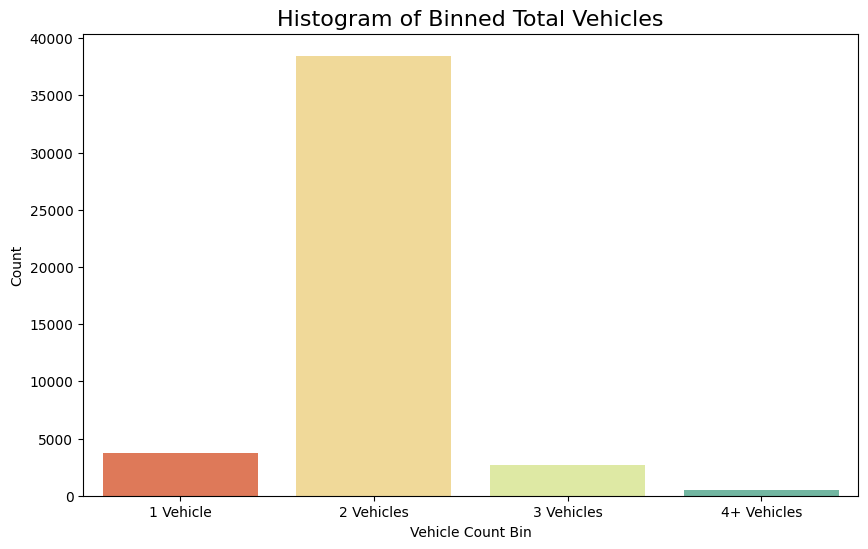

In [6]:
print("Distribution of 'total_vehicles':")
print(df['total_vehicles'].value_counts().sort_index())

# Get the max number of vehicles
max_vehicles = df['total_vehicles'].max()

vehicle_bins = [0, 1, 2, 3, np.inf] 
vehicle_labels = ['1 Vehicle', '2 Vehicles', '3 Vehicles', '4+ Vehicles']

df['vehicle_bin'] = pd.cut(df['total_vehicles'], 
                           bins=vehicle_bins, 
                           labels=vehicle_labels)

print("\nDisplaying histogram of 'vehicle_bin'...")

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='vehicle_bin', palette='Spectral')
plt.title('Histogram of Binned Total Vehicles', fontsize=16)
plt.xlabel('Vehicle Count Bin')
plt.ylabel('Count')
plt.show()

### X-square Test of Discretized Attributes

In [7]:
print("--- Test 1: Vehicle Bins vs. Injury ---")
contingency_table_veh = pd.crosstab(df['vehicle_bin'], df['injury'])
print("Contingency Table:")
print(contingency_table_veh)

# Run the test
chi2, p_val, dof, expected = chi2_contingency(contingency_table_veh)
print(f"\nChi-Square Value: {chi2}")
print(f"P-Value: {p_val}")

if p_val < 0.05:
    print("Result: The variables are DEPENDENT (p < 0.05).")
else:
    print("Result: The variables are INDEPENDENT (p > 0.05).")

print("\n\n--- Test 2: Latitude Bins vs. Longitude Bins ---")
contingency_table_loc = pd.crosstab(df['lat_bin'], df['lon_bin'])
print("Contingency Table (snippet):")
print(contingency_table_loc.head())

chi2, p_val, dof, expected = chi2_contingency(contingency_table_loc)
print(f"\nChi-Square Value: {chi2}")
print(f"P-Value: {p_val}")

if p_val < 0.05:
    print("Result: The variables are DEPENDENT (p < 0.05).")
else:
    print("Result: The variables are INDEPENDENT (p > 0.05).")

--- Test 1: Vehicle Bins vs. Injury ---
Contingency Table:
injury          0      1
vehicle_bin             
1 Vehicle    1316   2436
2 Vehicles   7581  30886
3 Vehicles   1104   1553
4+ Vehicles   267    242

Chi-Square Value: 1321.5834028096037
P-Value: 3.0522913539131864e-286
Result: The variables are DEPENDENT (p < 0.05).


--- Test 2: Latitude Bins vs. Longitude Bins ---
Contingency Table (snippet):
lon_bin  Lon_Q1  Lon_Q2  Lon_Q3  Lon_Q4
lat_bin                                
Lat_Q1     2377    1987    4402    2581
Lat_Q2     2324    3351    1262    4410
Lat_Q3     3742    1959    2681    2963
Lat_Q4     2905    4051    2998    1392

Chi-Square Value: 4989.898133978713
P-Value: 0.0
Result: The variables are DEPENDENT (p < 0.05).


Test 1: Vehicle Bins vs. Injury
P-Value: 3.05e-286. This is an extremely small number (0.000... with 285 zeros).

Result: DEPENDENT.

What it means: There is a strong, statistically significant relationship between the number of vehicles in a crash and whether an injury occurs. This confirms our intuition that vehicle_bin is a very important predictive feature.

Deeper Insight (from your Contingency Table):

1 Vehicle: 1316 (No Injury) vs. 2436 (Injury) → ~65% injury rate

2 Vehicles: 7581 (No Injury) vs. 30886 (Injury) → ~80% injury rate

3 Vehicles: 1104 (No Injury) vs. 1553 (Injury) → ~58% injury rate

4+ Vehicles: 267 (No Injury) vs. 242 (Injury) → ~47.5% injury rate This is a fantastic insight! The highest risk of injury is in 2-vehicle crashes, not 1-vehicle or multi-car pileups.

Test 2: Latitude Bins vs. Longitude Bins
P-Value: 0.0.

Result: DEPENDENT.

What it means: The geographic "zones" you created are not independent. A crash's latitude bin is related to its longitude bin.

This is expected. It simply means the city's layout isn't a perfect square. For example, your Lat_Q1 (southernmost) zone might be very wide, while your Lat_Q4 (northernmost) zone might be very narrow. Your contingency table snippet shows this: Lat_Q1 has a high number of crashes in Lon_Q3, but Lat_Q4 has a high number in Lon_Q2. This just confirms the geographic distribution of crashes is complex.


In [8]:
df.columns

Index(['crash_date', 'district', 'zone', 'crash_occurred_on',
       'type_of_roadway', 'road_surface', 'weather_condition',
       'lighting_condition', 'injury', 'fatality', 'hit_and_run',
       'pedestrian_involved', 'train_involved', 'intersection',
       'total_vehicles', 'vehicle_alignment', 'relation_to_roadway',
       'manner_of_collision', 'primary_factor', 'secondary_factor', 'latitude',
       'longitude', 'day_of_week', 'crash_month', 'lat_bin', 'lon_bin',
       'vehicle_bin'],
      dtype='object')

In [9]:
# 1. List all categorical columns 
categorical_cols = [
    'district', 'zone', 'crash_occurred_on', 'type_of_roadway', 
    'road_surface', 'weather_condition', 'lighting_condition', 'injury', 
    'fatality', 'hit_and_run', 'pedestrian_involved', 'train_involved', 
    'intersection', 'vehicle_alignment', 'relation_to_roadway', 
    'manner_of_collision', 'primary_factor', 'secondary_factor', 
    'day_of_week', 'crash_month', 'vehicle_bin', 'lat_bin', 'lon_bin'
]


all_pairs = list(itertools.combinations(categorical_cols, 2))
print(f"\nFound {len(categorical_cols)} categorical columns.")
print(f"Total number of pairs to test: {len(all_pairs)}")

results = []
significance_level = 0.05

# 4. Loop through all pairs and perform the test
print("Running Chi-square tests for all pairs...")
for col1, col2 in all_pairs:
    try:
        # Create contingency table
        contingency_table = pd.crosstab(df[col1], df[col2])
        chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)
        
        warning = ""
        if (expected_freq < 5).sum() > 0:
            warning = "Warning: (%.1f%%) of cells have expected frequency < 5. Result may be unreliable." % ((expected_freq < 5).mean() * 100)
        
        results.append({
            'Variable 1': col1,
            'Variable 2': col2,
            'Chi2 Statistic': chi2_stat,
            'P-Value': p_value,
            'Significant (p < 0.05)': p_value < significance_level,
            'Warning': warning
        })
    
    except Exception as e:
        results.append({
            'Variable 1': col1,
            'Variable 2': col2,
            'Chi2 Statistic': np.nan,
            'P-Value': np.nan,
            'Significant (p < 0.05)': False,
            'Warning': f"ERROR: {str(e)}"
        })

results_df = pd.DataFrame(results)

significant_results = results_df[results_df['Significant (p < 0.05)'] == True]
significant_results = significant_results.sort_values(by='P-Value', ascending=True)

print("\n--- All Significant Relationships (p < 0.05) ---")
print("--- (Sorted by most significant) ---")
if significant_results.empty:
    print("No significant relationships found at the p < 0.05 level.")
else:
    print(significant_results.to_string(index=False, columns=['Variable 1', 'Variable 2', 'P-Value', 'Warning']))

full_csv_path = "all_chi2_test_results.csv"
results_df.to_csv(full_csv_path, index=False)

print(f"\nDone. Full report for all {len(all_pairs)} pairs saved to: {full_csv_path}")


Found 23 categorical columns.
Total number of pairs to test: 253
Running Chi-square tests for all pairs...

--- All Significant Relationships (p < 0.05) ---
--- (Sorted by most significant) ---
         Variable 1          Variable 2       P-Value                                                                          Warning
           district                zone  0.000000e+00 Warning: (14.4%) of cells have expected frequency < 5. Result may be unreliable.
  weather_condition      primary_factor  0.000000e+00 Warning: (64.8%) of cells have expected frequency < 5. Result may be unreliable.
  weather_condition  lighting_condition  0.000000e+00 Warning: (50.0%) of cells have expected frequency < 5. Result may be unreliable.
       road_surface    secondary_factor  0.000000e+00 Warning: (72.7%) of cells have expected frequency < 5. Result may be unreliable.
       road_surface      primary_factor  0.000000e+00 Warning: (75.0%) of cells have expected frequency < 5. Result may be unrelia

In [10]:
results_df.tail(20)

,Variable 1,Variable 2,Chi2 Statistic,P-Value,Significant (p < 0.05),Warning
233,primary_factor,day_of_week,160.512490,7.650074e-10,True,Warning: (22.6%) of cells have expected freque...
234,primary_factor,crash_month,218.399886,1.417127e-07,True,Warning: (25.0%) of cells have expected freque...
235,primary_factor,vehicle_bin,4301.555652,0.000000e+00,True,Warning: (33.3%) of cells have expected freque...
236,primary_factor,lat_bin,406.030605,8.268105e-66,True,Warning: (16.7%) of cells have expected freque...
237,primary_factor,lon_bin,227.771152,5.795339e-31,True,Warning: (16.7%) of cells have expected freque...
238,secondary_factor,day_of_week,345.562150,2.279222e-37,True,Warning: (17.6%) of cells have expected freque...
239,secondary_factor,crash_month,274.021840,5.544665e-12,True,Warning: (29.5%) of cells have expected freque...
240,secondary_factor,vehicle_bin,1988.295056,0.000000e+00,True,Warning: (32.7%) of cells have expected freque...
241,secondary_factor,lat_bin,225.901747,2.312980e-29,True,Warning: (7.7%) of cells have expected frequen...
242,secondary_factor,lon_bin,745.893185,1.653793e-133,True,Warning: (7.7%) of cells have expected frequen...


### Association Matrix

Generating heatmap...


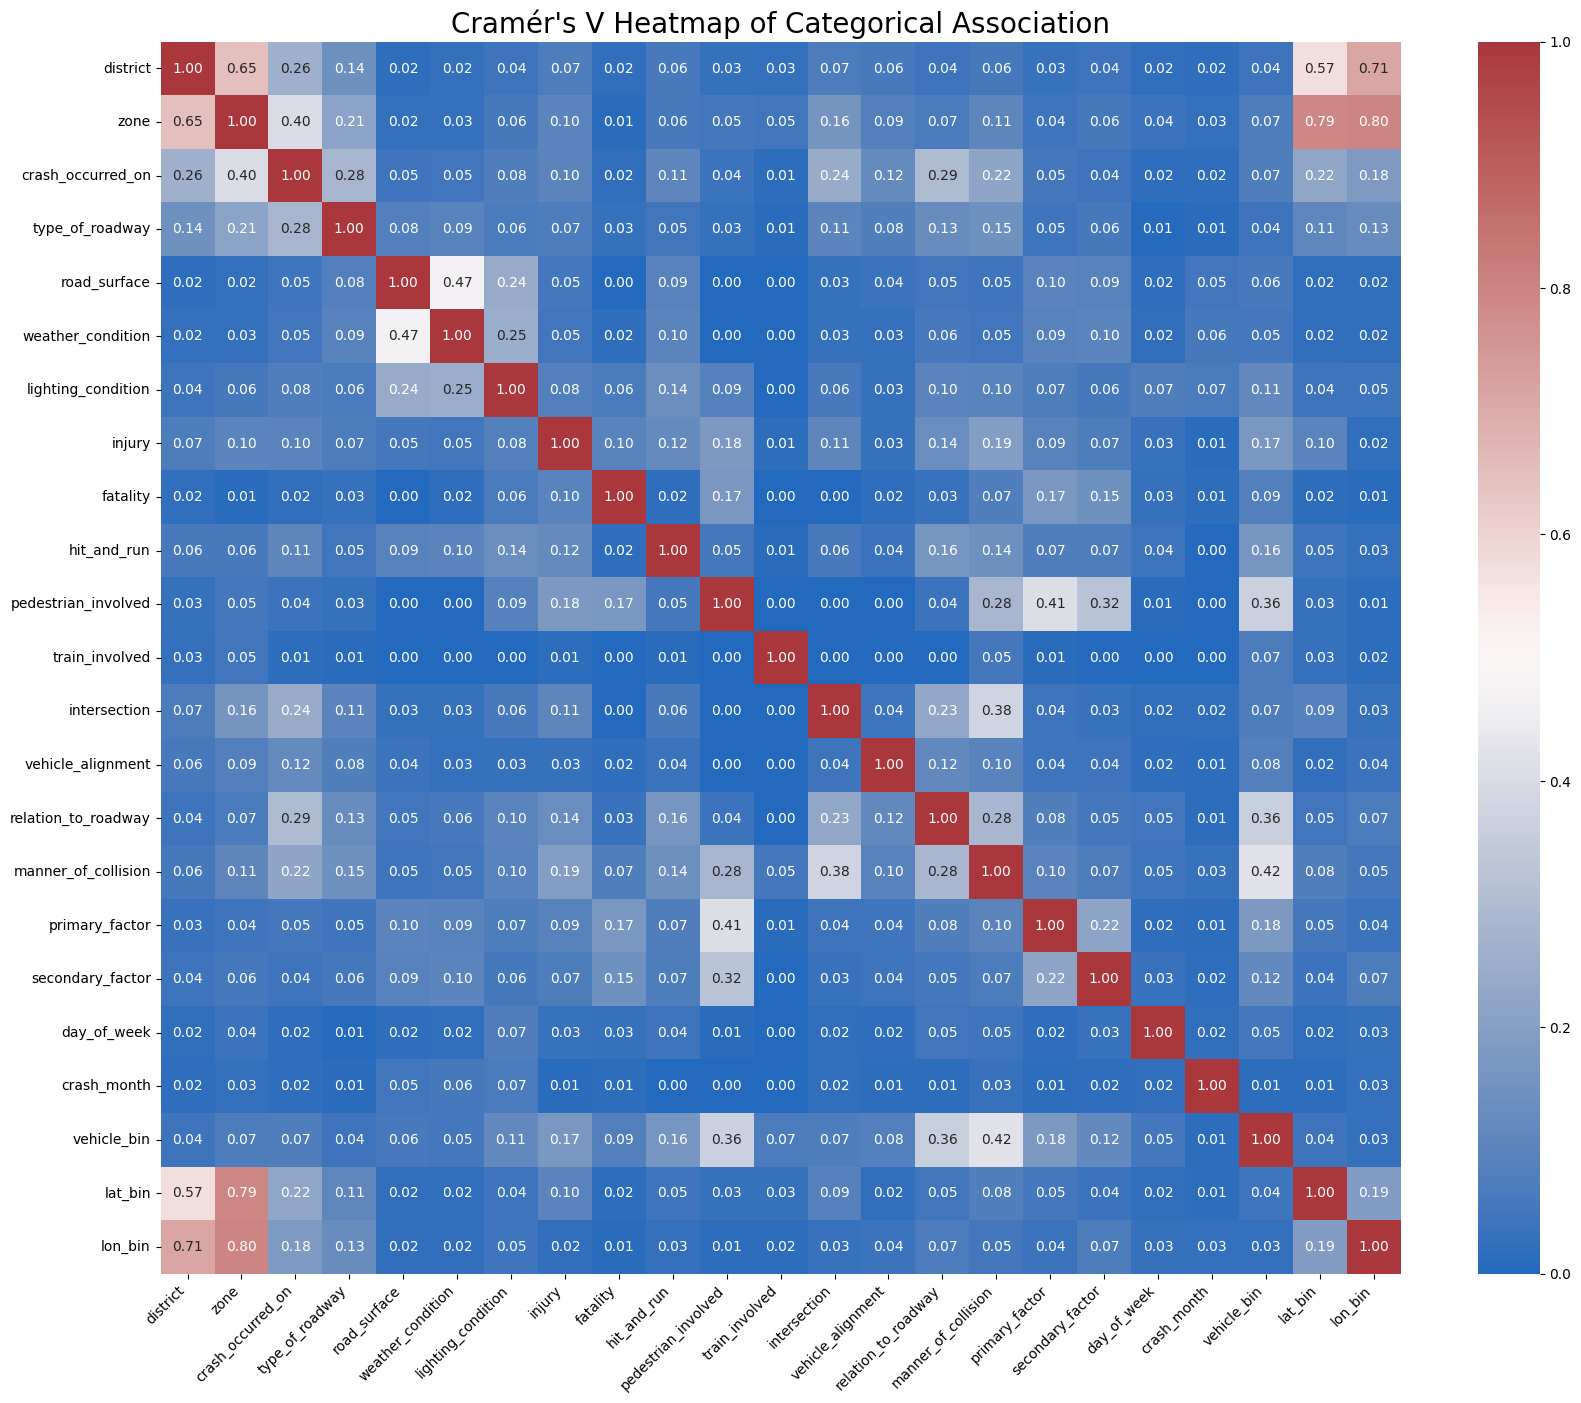

In [11]:

# --- Calculate Cramér's V ---
def cramers_v(contingency_table):
    """ Calculate Cramér's V statistic for categorical-categorical association. """
    try:
        chi2 = chi2_contingency(contingency_table)[0]
        n = contingency_table.sum().sum()
        phi2 = chi2 / n
        r, k = contingency_table.shape
        phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
        r_corr = r - ((r-1)**2)/(n-1)
        k_corr = k - ((k-1)**2)/(n-1)
        
        if min((k_corr-1), (r_corr-1)) == 0:
            return 0
        else:
            return np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))
    except Exception as e:
        return 0

# --- Association Matrix
assoc_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols, dtype=float)

for col1, col2 in itertools.combinations(categorical_cols, 2):
    ct = pd.crosstab(df[col1], df[col2])
    v = cramers_v(ct)
    assoc_matrix.loc[col1, col2] = v
    assoc_matrix.loc[col2, col1] = v

np.fill_diagonal(assoc_matrix.values, 1.0)

# Plot the Heatmap 
print("Generating heatmap...")
plt.figure(figsize=(20, 16))
sns.heatmap(assoc_matrix, annot=True, cmap='vlag', fmt='.2f', vmin=0, vmax=1)
plt.title("Cramér's V Heatmap of Categorical Association", fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
# plt.savefig('cramers_v_heatmap.png', bbox_inches='tight', dpi=150)


In [12]:
df.drop(['crash_date', 'lat_bin', 'lon_bin', 'total_vehicles', 'zone', 'latitude', 'longitude'], axis=1, inplace=True)

In [13]:
df_cluster = df.copy()

### Grouping

In [14]:
print("\nGrouping 'day_of_week'...")
if 'day_of_week' in df_cluster.columns:
    weekend_days = ['saturday', 'sunday']
    df_cluster['is_weekend'] = df_cluster['day_of_week'].isin(weekend_days).astype(int)
    
    df_cluster = df_cluster.drop('day_of_week', axis=1)
    
    print("New 'is_weekend' counts:")
    print(df_cluster['is_weekend'].value_counts())


print("\nGrouping 'crash_month'...")
if 'crash_month' in df_cluster.columns:
    season_map = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    }
    df_cluster['season'] = df_cluster['crash_month'].map(season_map)
    
    df_cluster = df_cluster.drop('crash_month', axis=1)
    
    print("New 'season' counts:")
    print(df_cluster['season'].value_counts())


print("\nGrouping 'lighting_condition'...")
if 'lighting_condition' in df_cluster.columns:
    light_map = {
        'daylight': 'Daylight',
        'dawn/dusk': 'Twilight',
        'dark - not lighted': 'Dark',
        'dark - continuous street lights': 'Dark',
        'dark - street lights at intersection only': 'Dark',
        'dark - unknown lighting': 'Dark',
        'unknown': 'Unknown/Other',
        'other': 'Unknown/Other'
    }
    df_cluster['light_group'] = df_cluster['lighting_condition'].map(light_map)
    
    df_cluster['light_group'] = df_cluster['light_group'].fillna('Unknown/Other')
    df_cluster = df_cluster.drop('lighting_condition', axis=1)

    print("New 'light_group' counts:")
    print(df_cluster['light_group'].value_counts())

print("\nGrouping 'weather_condition'...")
if 'weather_condition' in df_cluster.columns:
    weather_map = {
        'clear': 'Clear/Cloudy',
        'cloudy': 'Clear/Cloudy',
        'rain': 'Rain',
        'freezing rain': 'Snow/Ice',
        'snow': 'Snow/Ice',
        'fog': 'Obscured',
        'severe crosswinds': 'Other/Unknown',
        'unknown': 'Other/Unknown',
        'other': 'Other/Unknown'
    }
    df_cluster['weather_group'] = df_cluster['weather_condition'].map(weather_map)
    
    df_cluster['weather_group'] = df_cluster['weather_group'].fillna('Other/Unknown')
    
    df_cluster = df_cluster.drop('weather_condition', axis=1)

    print("New 'weather_group' counts:")
    print(df_cluster['weather_group'].value_counts())


Grouping 'day_of_week'...
New 'is_weekend' counts:
is_weekend
0    35245
1    10140
Name: count, dtype: int64

Grouping 'crash_month'...
New 'season' counts:
season
Fall      12441
Spring    11749
Summer    10785
Winter    10410
Name: count, dtype: int64

Grouping 'lighting_condition'...
New 'light_group' counts:
light_group
Daylight         33292
Dark             10263
Twilight          1061
Unknown/Other      769
Name: count, dtype: int64

Grouping 'weather_condition'...
New 'weather_group' counts:
weather_group
Clear/Cloudy     41748
Rain              2832
Other/Unknown      699
Obscured            71
Snow/Ice            35
Name: count, dtype: int64


### Encoder

In [15]:
encoder = OrdinalEncoder()
df_encoded = df_cluster.copy()
cat_cols = df_cluster.select_dtypes(include=['object', 'category']).columns

df_encoded[cat_cols] = encoder.fit_transform(df_cluster[cat_cols])


In [16]:
df_encoded.head()

,district,crash_occurred_on,type_of_roadway,road_surface,injury,fatality,hit_and_run,pedestrian_involved,train_involved,intersection,vehicle_alignment,relation_to_roadway,manner_of_collision,primary_factor,secondary_factor,vehicle_bin,is_weekend,season,light_group,weather_group
0,10,1.0,0.0,0.0,1,0,1,0,0,False,3.0,4.0,5.0,9.0,2.0,1.0,0,0.0,0.0,0.0
1,11,0.0,2.0,0.0,1,0,0,0,0,True,3.0,4.0,4.0,9.0,2.0,1.0,0,0.0,1.0,0.0
2,8,0.0,2.0,0.0,1,0,0,0,0,True,3.0,4.0,0.0,9.0,2.0,1.0,0,0.0,1.0,0.0
3,8,0.0,2.0,0.0,1,0,0,0,0,False,3.0,4.0,0.0,9.0,2.0,1.0,0,0.0,1.0,0.0
4,9,0.0,2.0,0.0,1,0,0,0,0,False,3.0,4.0,4.0,9.0,2.0,1.0,0,0.0,1.0,0.0


In [17]:
df_encoded.shape

(45385, 20)

In [18]:
# Standard Scaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

## Dimensionality Reduction

### PCA

In [19]:
# Performing PCA
pca = PCA(n_components=None)
X_pca = pca.fit_transform(df_scaled)


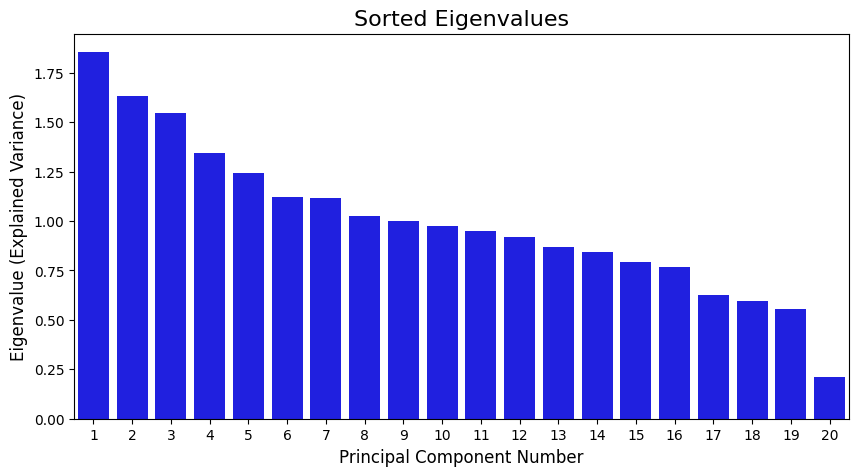

In [20]:
eigenvalues = pca.explained_variance_

plt.figure(figsize=(10, 5))
sns.barplot(
    x=list(range(1, len(eigenvalues) + 1)), 
    y=eigenvalues,
    color='b'
)
plt.title('Sorted Eigenvalues', fontsize=16)
plt.xlabel('Principal Component Number', fontsize=12)
plt.ylabel('Eigenvalue (Explained Variance)', fontsize=12)

plt.xlabel('Principal Component Number', fontsize=12)

plt.show()

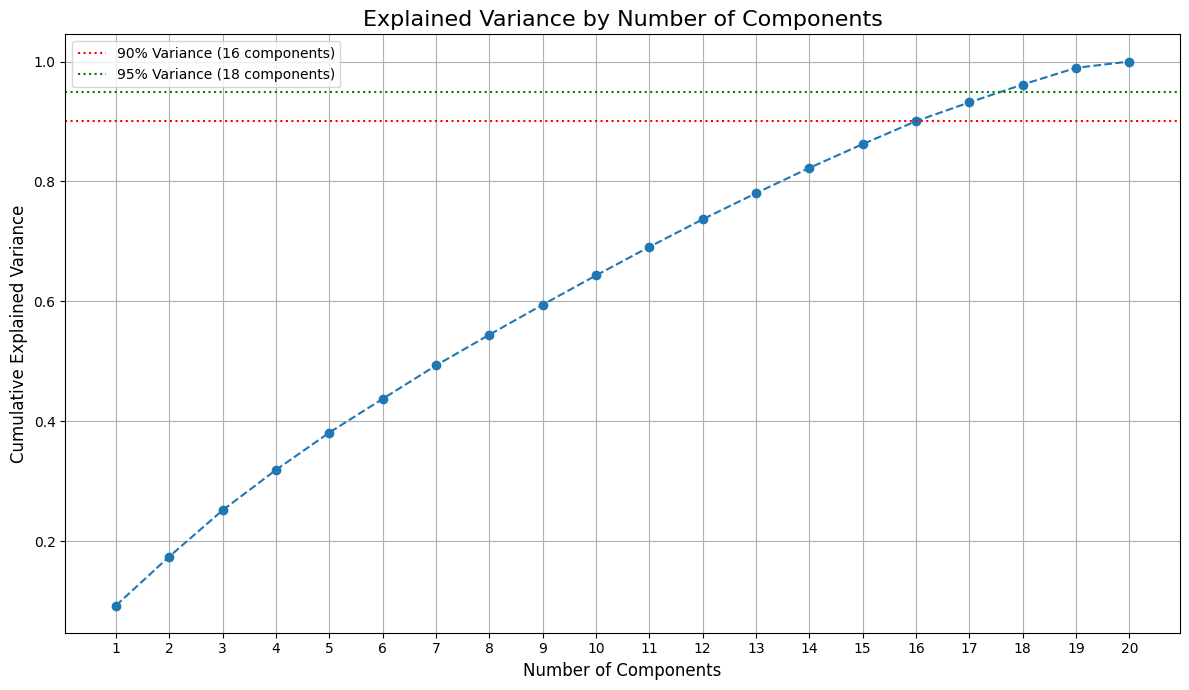

To capture 90% of variance, you need 16 components.
To capture 95% of variance, you need 18 components.


In [21]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
plt.axhline(y=0.90, color='r', linestyle=':', label=f'90% Variance ({n_components_90} components)')

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
plt.axhline(y=0.95, color='g', linestyle=':', label=f'95% Variance ({n_components_95} components)')

plt.title('Explained Variance by Number of Components', fontsize=16)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.grid(True)
plt.legend()

ax = plt.gca()
if len(cumulative_variance) <= 20:
    plt.xticks(range(1, len(cumulative_variance) + 1))
else:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

print(f"To capture 90% of variance, you need {n_components_90} components.")
print(f"To capture 95% of variance, you need {n_components_95} components.")

In [22]:
len(eigenvalues)

20

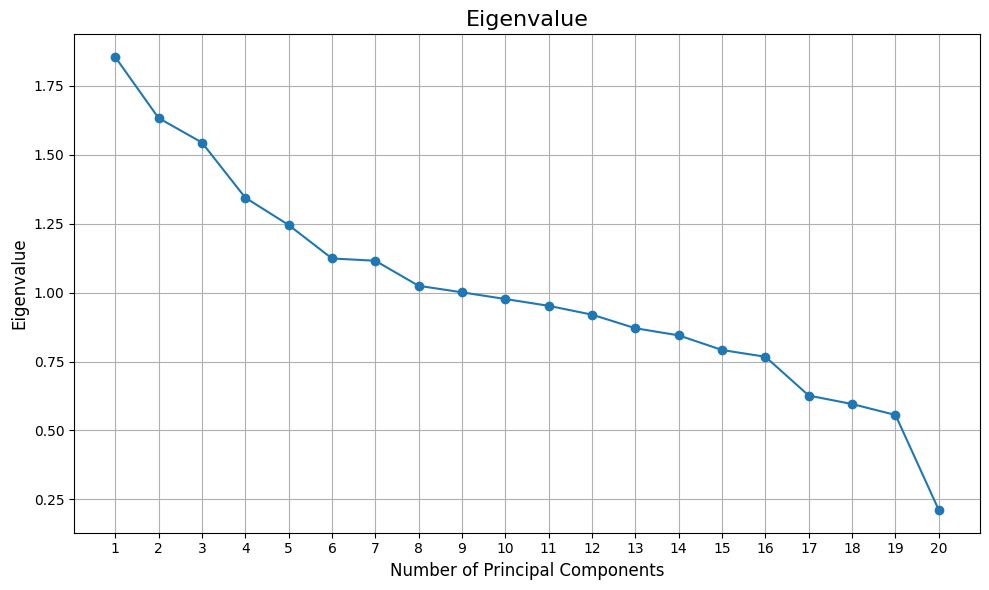

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-')

plt.title('Eigenvalue', fontsize=16)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Eigenvalue', fontsize=12)
plt.grid(True)

ax = plt.gca()
if len(cumulative_variance) <= 20:
    plt.xticks(range(1, len(cumulative_variance) + 1))
else:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [24]:
n_components_analysis = 18

pca_analysis = PCA(n_components=n_components_analysis)
df_pca_analysis = pca_analysis.fit_transform(df_scaled)


In [25]:
pca_visual = PCA(n_components=18)
df_pca_visual = pca_visual.fit_transform(df_scaled)
df_pca_visual = pd.DataFrame(df_pca_visual, columns=['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'PCA8', 'PCA9', 'PCA10', 'PCA11', 'PCA12', 'PCA13', 'PCA14', 'PCA15', 'PCA16', 'PCA17', 'PCA18'])

n_sample = df_encoded.shape[0]
sample_indices = np.random.choice(df_pca_analysis.shape[0], n_sample, replace=False)
df_pca_sample = df_pca_analysis[sample_indices]

### Hierarchical Clustering (Dendrogram)

In [26]:
print(f"Running linkage on sample of {n_sample} rows...")
Z = linkage(df_pca_sample, method='ward')

Running linkage on sample of 45385 rows...


Plotting dendrogram...


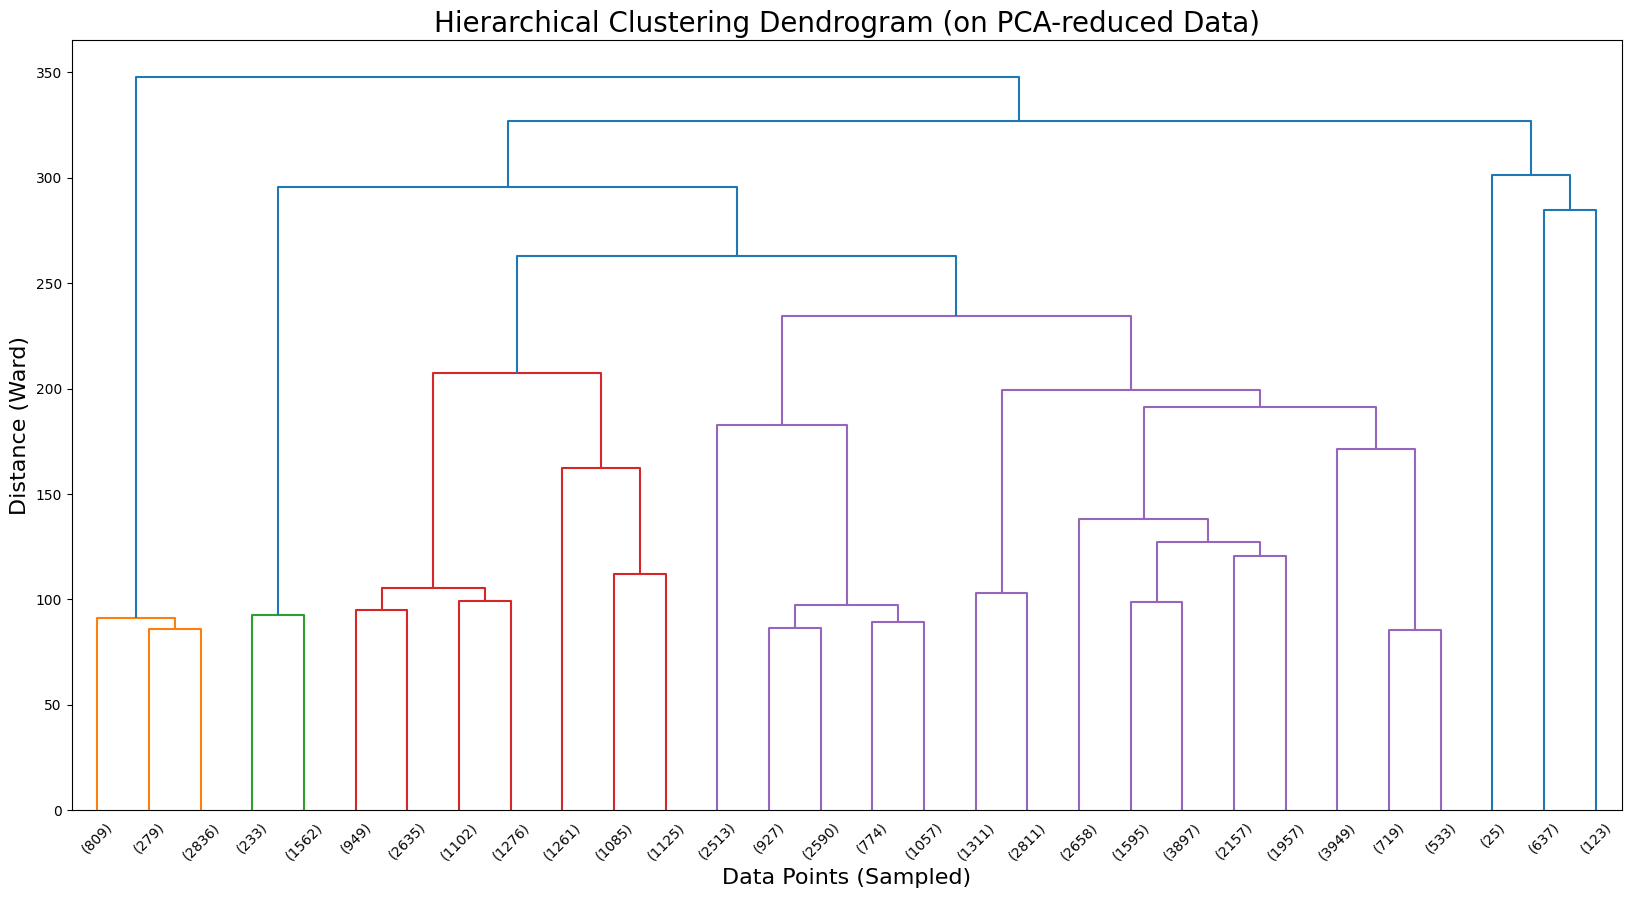

In [27]:
print("Plotting dendrogram...")
plt.figure(figsize=(20, 10))
plt.title('Hierarchical Clustering Dendrogram (on PCA-reduced Data)', fontsize=20)
plt.xlabel('Data Points (Sampled)', fontsize=16)
plt.ylabel('Distance (Ward)', fontsize=16)
dendrogram(Z, truncate_mode='lastp', p=30)
plt.show()

### Agglomerative Clustering

In [28]:
hier = AgglomerativeClustering(n_clusters=18, linkage='ward')
labels_hier = hier.fit_predict(df_pca_analysis)

In [29]:
min_samples = 2 * n_components_analysis

### DBSCAN

In [30]:
from kneed import KneeLocator

# X_pca from earlier step
def get_eps_optimal(k):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X_pca)
    distances, indices = neighbors_fit.kneighbors(X_pca)

    # Take the distance to the k-th nearest neighbor
    k_distances = np.sort(distances[:, k-1])
    kneedle = KneeLocator(range(len(k_distances)), k_distances, curve='convex', direction='increasing')
    eps_optimal = k_distances[kneedle.knee]
    return eps_optimal

print(get_eps_optimal(min_samples))

Python(21290) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


5.864985515332487


### Silhouette Score

In [31]:
min_samples = range(12, 37, 6)
for ms in min_samples:
    eps = get_eps_optimal(ms)
    db = DBSCAN(eps=eps, min_samples=ms).fit(X_pca)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = list(labels).count(-1)/len(labels)
    if n_clusters > 1:
        score = silhouette_score(X_pca, labels)
        print(f"eps={eps:.1f}, min_samples={ms}, clusters={n_clusters}, noise={noise_ratio:.2f}, silhouette={score:.3f}")
    else:
        print(f"eps={eps:.1f}, min_samples={ms}, clusters=1, noise={noise_ratio:.2f}")

eps=4.9, min_samples=12, clusters=5, noise=0.00, silhouette=0.455
eps=4.8, min_samples=18, clusters=5, noise=0.00, silhouette=0.455
eps=7.9, min_samples=24, clusters=5, noise=0.00, silhouette=0.457
eps=5.5, min_samples=30, clusters=4, noise=0.00, silhouette=0.456
eps=5.9, min_samples=36, clusters=4, noise=0.00, silhouette=0.457


In [32]:
min_samples = range(40, 101, 10)
for ms in min_samples:
    eps = get_eps_optimal(ms)
    db = DBSCAN(eps=eps, min_samples=ms).fit(X_pca)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = list(labels).count(-1)/len(labels)
    if n_clusters > 1:
        score = silhouette_score(X_pca, labels)
        print(f"eps={eps:.1f}, min_samples={ms}, clusters={n_clusters}, noise={noise_ratio:.2f}, silhouette={score:.3f}")
    else:
        print(f"eps={eps:.1f}, min_samples={ms}, clusters=1, noise={noise_ratio:.2f}")

eps=42.7, min_samples=40, clusters=1, noise=0.00
eps=42.7, min_samples=50, clusters=1, noise=0.00
eps=42.7, min_samples=60, clusters=1, noise=0.00
eps=42.7, min_samples=70, clusters=1, noise=0.00
eps=9.8, min_samples=80, clusters=2, noise=0.00, silhouette=0.726
eps=5.9, min_samples=90, clusters=2, noise=0.00, silhouette=0.456
eps=6.2, min_samples=100, clusters=2, noise=0.00, silhouette=0.456


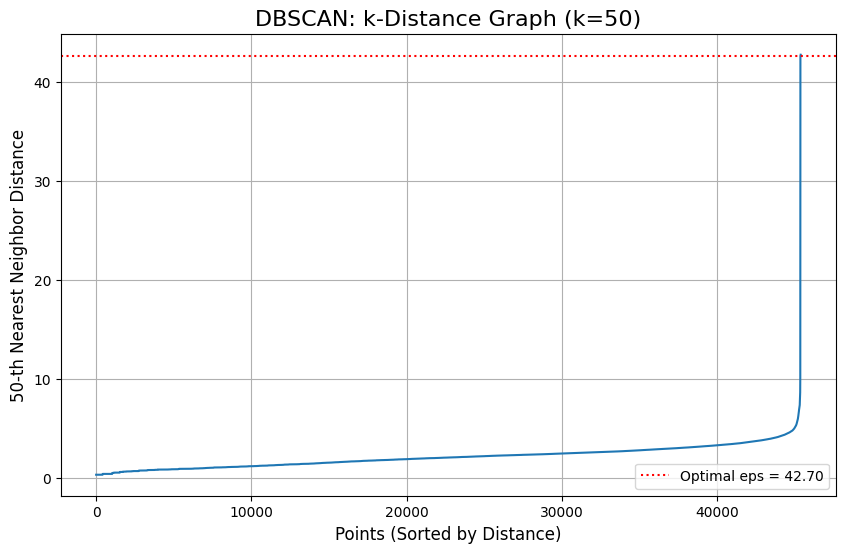

In [33]:
min_samples = 50
eps_optimal = get_eps_optimal(min_samples)
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Take the distance to the k-th nearest neighbor
k_distances = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.axhline(y=eps_optimal, color='r', linestyle=':', label=f'Optimal eps = {eps_optimal:.2f}')
plt.title(f'DBSCAN: k-Distance Graph (k={min_samples})', fontsize=16)
plt.xlabel('Points (Sorted by Distance)', fontsize=12)
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

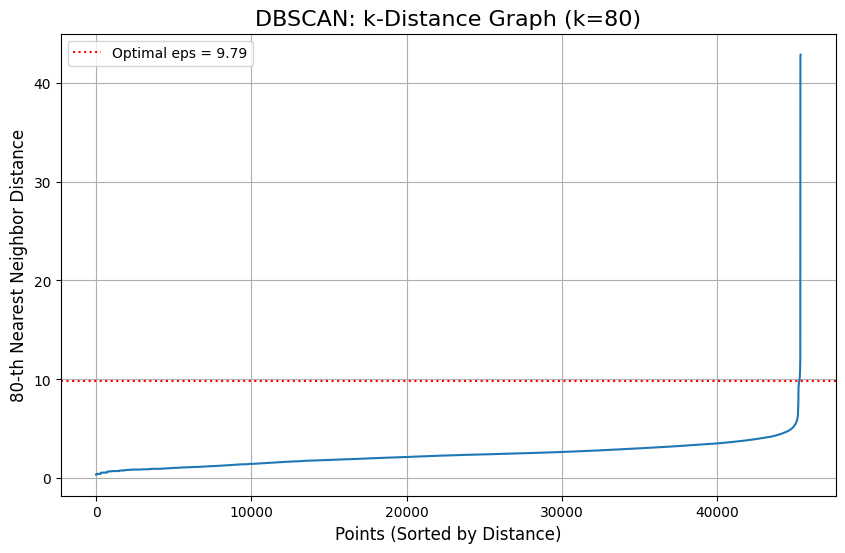

In [34]:
min_samples = 80
eps_optimal = get_eps_optimal(min_samples)
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Take the distance to the k-th nearest neighbor
k_distances = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.axhline(y=eps_optimal, color='r', linestyle=':', label=f'Optimal eps = {eps_optimal:.2f}')
plt.title(f'DBSCAN: k-Distance Graph (k={min_samples})', fontsize=16)
plt.xlabel('Points (Sorted by Distance)', fontsize=12)
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

Running DBSCAN with eps=6.3 and min_samples-1=50...

DBSCAN found 4 clusters.
Found 28 noise points (cluster -1).
Plotting DBSCAN cluster results...


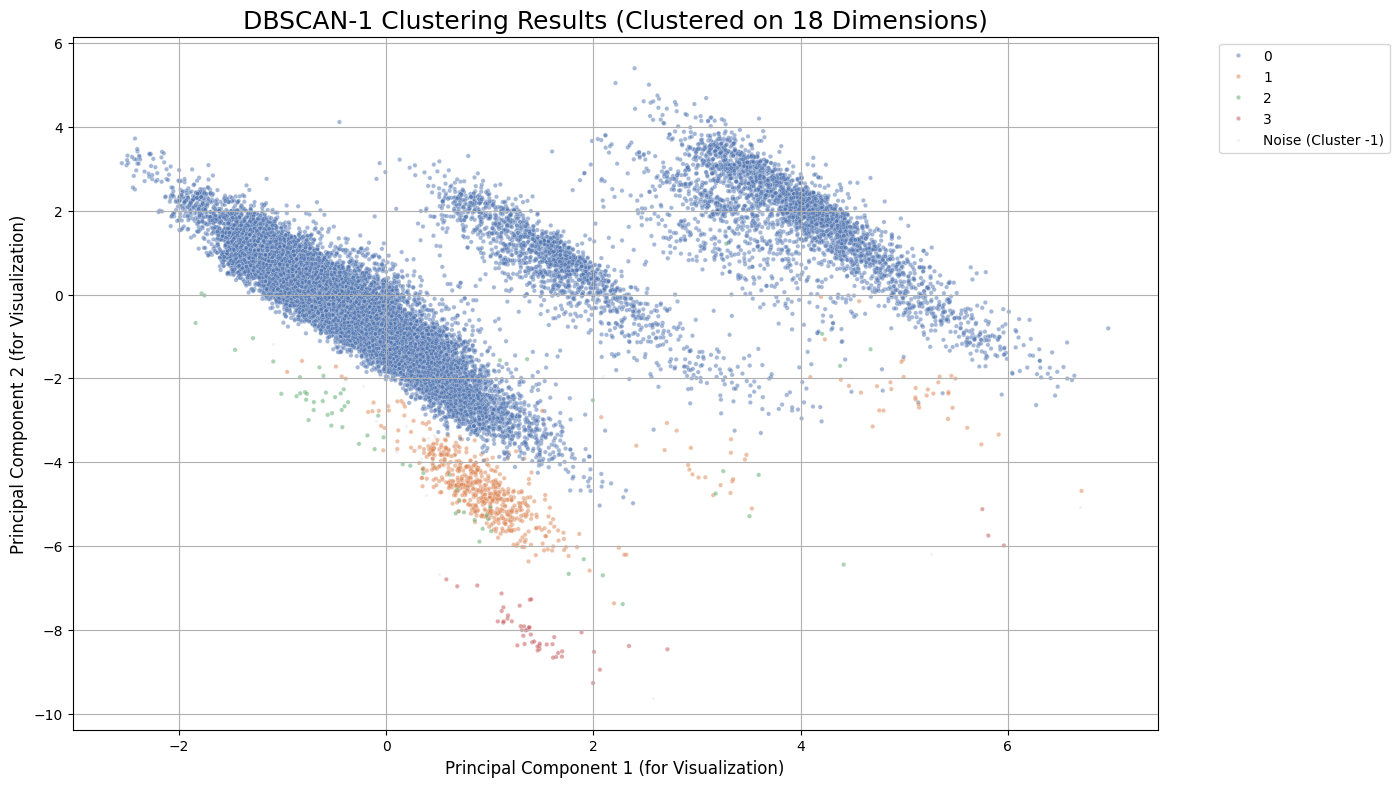

In [ ]:
min_samples_1 = 50
eps_optimal_1 = get_eps_optimal(min_samples_1)
print(f"Running DBSCAN with eps={eps_optimal_1} and min_samples-1={min_samples_1}...")
dbscan_1 = DBSCAN(eps=eps_optimal_1, min_samples=min_samples_1, n_jobs=-1)
db_labels_1 = dbscan_1.fit_predict(df_pca_analysis)

df_pca_visual['db_cluster_1'] = db_labels_1
n_clusters_1 = len(set(db_labels_1)) - (1 if -1 in db_labels_1 else 0)
n_noise_1 = list(db_labels_1).count(-1)

print(f"\nDBSCAN found {n_clusters_1} clusters.")
print(f"Found {n_noise_1} noise points (cluster -1).")

print("Plotting DBSCAN cluster results...")
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_pca_visual[df_pca_visual['db_cluster_1'] != -1], 
    x='PCA1', y='PCA2', hue='db_cluster_1', 
    palette='deep', s=10, alpha=0.5
)
sns.scatterplot(
    data=df_pca_visual[df_pca_visual['db_cluster_1'] == -1], 
    x='PCA1', y='PCA2', color='gray', 
    label='Noise (Cluster -1)', s=5, alpha=0.1
)
plt.title(f'DBSCAN-1 Clustering Results (Clustered on {n_components_analysis} Dimensions)', fontsize=18)
plt.xlabel('Principal Component 1 (for Visualization)', fontsize=12)
plt.ylabel('Principal Component 2 (for Visualization)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [67]:
# Add the cluster labels as a new column
df_cluster['db_cluster_1'] = db_labels_1
# Get a high-level summary of cluster sizes
print("Cluster sizes:")
print(df_cluster['db_cluster_1'].value_counts())

Cluster sizes:
db_cluster_1
 0    44600
 1      637
 2       70
 3       50
-1       28
Name: count, dtype: int64


In [68]:
cluster_ids = sorted([c for c in df_cluster['db_cluster_1'].unique() if c != -1])

for cluster_id in cluster_ids:
    print("\n" + "="*50)
    print(f"--- PROFILING CLUSTER {cluster_id} ---")

    cluster_df = df_cluster[df_cluster['db_cluster_1'] == cluster_id]
    
    print(f"Total points in cluster: {len(cluster_df)}")
    
    if 'primary_factor' in cluster_df.columns:
        print("\nPrimary Factor:")
        print(cluster_df['primary_factor'].value_counts(normalize=True).head(3))
        
    if 'manner_of_collision' in cluster_df.columns:
        print("\nManner of Collision:")
        print(cluster_df['manner_of_collision'].value_counts(normalize=True).head(3))

    if 'light_group' in cluster_df.columns:
        print("\nLighting Condition:")
        print(cluster_df['light_group'].value_counts(normalize=True).head(3))

    if 'weather_group' in cluster_df.columns:
        print("\nWeather Condition:")
        print(cluster_df['weather_group'].value_counts(normalize=True).head(3))

    if 'is_weekend' in cluster_df.columns:
        print("\nWeekend vs. Weekday:")
        print(cluster_df['is_weekend'].value_counts(normalize=True).head(3))

print("\n" + "="*50)
print("Analysis complete. Compare these profiles to understand your clusters.")


--- PROFILING CLUSTER 0 ---
Total points in cluster: 44600

Primary Factor:
primary_factor
violations                 0.761726
movement prior to crash    0.201345
driver condition           0.018543
Name: proportion, dtype: float64

Manner of Collision:
manner_of_collision
Rear-End     0.338924
Angle        0.255179
Sideswipe    0.198767
Name: proportion, dtype: float64

Lighting Condition:
light_group
Daylight    0.737713
Dark        0.222063
Twilight    0.023363
Name: proportion, dtype: float64

Weather Condition:
weather_group
Clear/Cloudy     0.919552
Rain             0.062713
Other/Unknown    0.015404
Name: proportion, dtype: float64

Weekend vs. Weekday:
is_weekend
0    0.777377
1    0.222623
Name: proportion, dtype: float64

--- PROFILING CLUSTER 1 ---
Total points in cluster: 637

Primary Factor:
primary_factor
violations                 0.585557
movement prior to crash    0.213501
non-motorist action        0.130298
Name: proportion, dtype: float64

Manner of Collision:
manne

Running DBSCAN with eps=9.8 and min_samples-2=80...

DBSCAN found 2 clusters.
Found 25 noise points (cluster -1).
Plotting DBSCAN cluster results...


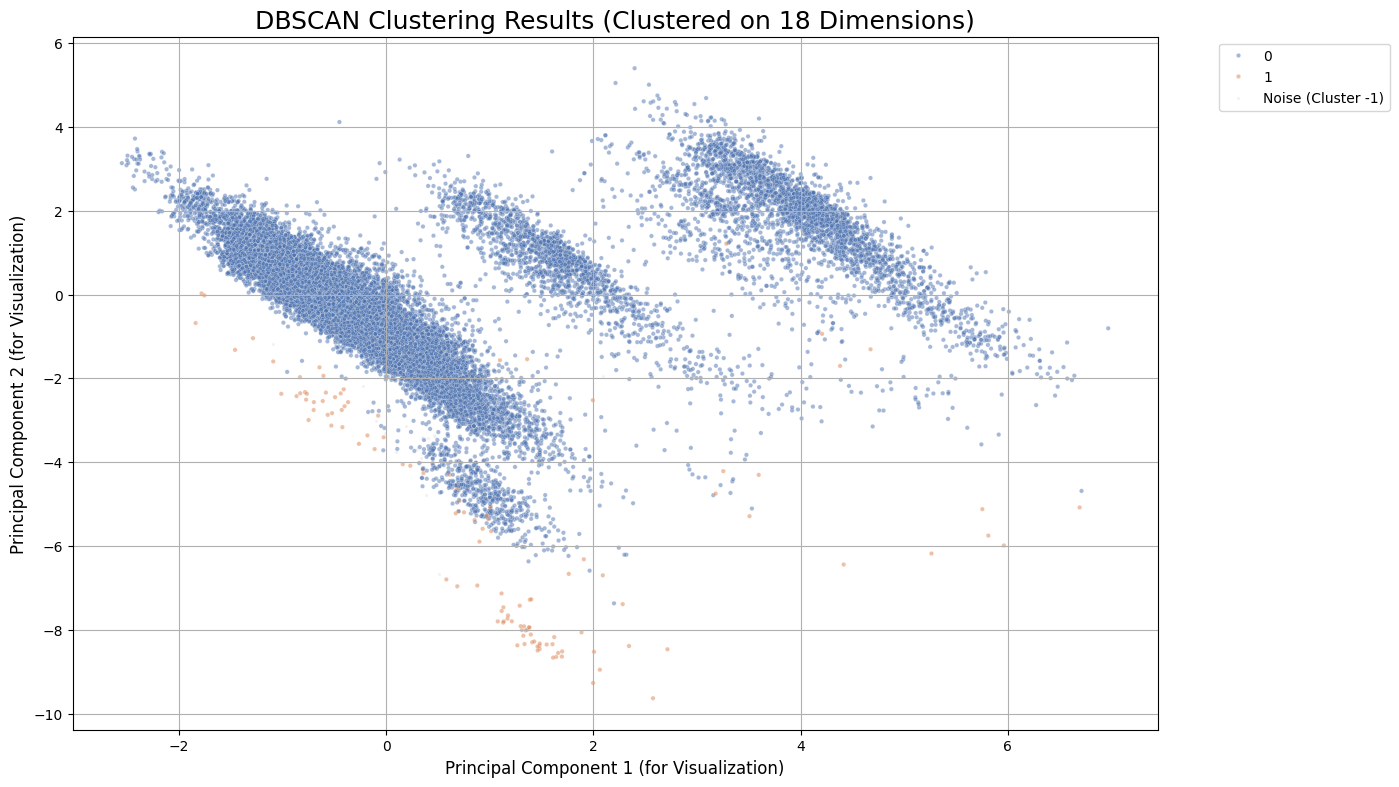

In [ ]:
min_samples_2 = 80
eps_optimal_2 = get_eps_optimal(min_samples_2)
print(f"Running DBSCAN with eps={eps_optimal_2} and min_samples-2={min_samples_2}...")
dbscan_2 = DBSCAN(eps=eps_optimal_2, min_samples=min_samples_2, n_jobs=-1)
db_labels_2 = dbscan_2.fit_predict(df_pca_analysis)

df_pca_visual['db_cluster_2'] = db_labels_2
n_clusters_2 = len(set(db_labels_2)) - (1 if -1 in db_labels_2 else 0)
n_noise_2 = list(db_labels_2).count(-1)

print(f"\nDBSCAN found {n_clusters_2} clusters.")
print(f"Found {n_noise_2} noise points (cluster -1).")

print("Plotting DBSCAN cluster results...")
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_pca_visual[df_pca_visual['db_cluster_2'] != -1], 
    x='PCA1', y='PCA2', hue='db_cluster_2', 
    palette='deep', s=10, alpha=0.5
)
sns.scatterplot(
    data=df_pca_visual[df_pca_visual['db_cluster_2'] == -1], 
    x='PCA1', y='PCA2', color='gray', 
    label='Noise (Cluster -1)', s=5, alpha=0.1
)
plt.title(f'DBSCAN Clustering Results (Clustered on {n_components_analysis} Dimensions)', fontsize=18)
plt.xlabel('Principal Component 1 (for Visualization)', fontsize=12)
plt.ylabel('Principal Component 2 (for Visualization)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [70]:
# Add the cluster labels as a new column
df_cluster['db_cluster_2'] = db_labels_2
# Get a high-level summary of cluster sizes
print("Cluster sizes:")
print(df_cluster['db_cluster_2'].value_counts())

Cluster sizes:
db_cluster_2
 0    45237
 1      123
-1       25
Name: count, dtype: int64


In [71]:
cluster_ids = sorted([c for c in df_cluster['db_cluster_2'].unique() if c != -1])

for cluster_id in cluster_ids:
    print("\n" + "="*50)
    print(f"--- PROFILING CLUSTER {cluster_id} ---")
    cluster_df = df_cluster[df_cluster['db_cluster_2'] == cluster_id]
    
    print(f"Total points in cluster: {len(cluster_df)}")
    
    if 'primary_factor' in cluster_df.columns:
        print("\nPrimary Factor:")
        print(cluster_df['primary_factor'].value_counts(normalize=True).head(3))
        
    if 'manner_of_collision' in cluster_df.columns:
        print("\nManner of Collision:")
        print(cluster_df['manner_of_collision'].value_counts(normalize=True).head(3))

    if 'light_group' in cluster_df.columns:
        print("\nLighting Condition:")
        print(cluster_df['light_group'].value_counts(normalize=True).head(3))

    if 'weather_group' in cluster_df.columns:
        print("\nWeather Condition:")
        print(cluster_df['weather_group'].value_counts(normalize=True).head(3))

    if 'is_weekend' in cluster_df.columns:
        print("\nWeekend vs. Weekday:")
        print(cluster_df['is_weekend'].value_counts(normalize=True).head(3))

print("\n" + "="*50)
print("Analysis complete. Compare these profiles to understand your clusters.")


--- PROFILING CLUSTER 0 ---
Total points in cluster: 45237

Primary Factor:
primary_factor
violations                 0.759246
movement prior to crash    0.201516
driver condition           0.018679
Name: proportion, dtype: float64

Manner of Collision:
manner_of_collision
Rear-End     0.334372
Angle        0.251741
Sideswipe    0.196123
Name: proportion, dtype: float64

Lighting Condition:
light_group
Daylight    0.734753
Dark        0.224860
Twilight    0.023410
Name: proportion, dtype: float64

Weather Condition:
weather_group
Clear/Cloudy     0.919844
Rain             0.062427
Other/Unknown    0.015430
Name: proportion, dtype: float64

Weekend vs. Weekday:
is_weekend
0    0.777129
1    0.222871
Name: proportion, dtype: float64

--- PROFILING CLUSTER 1 ---
Total points in cluster: 123

Primary Factor:
primary_factor
violations                 0.682927
non-motorist action        0.154472
movement prior to crash    0.081301
Name: proportion, dtype: float64

Manner of Collision:
manne

### K-Means


--- 3. K-Means Clustering ---
Calculating K-Means elbow plot...
Optimal K found at k = 6


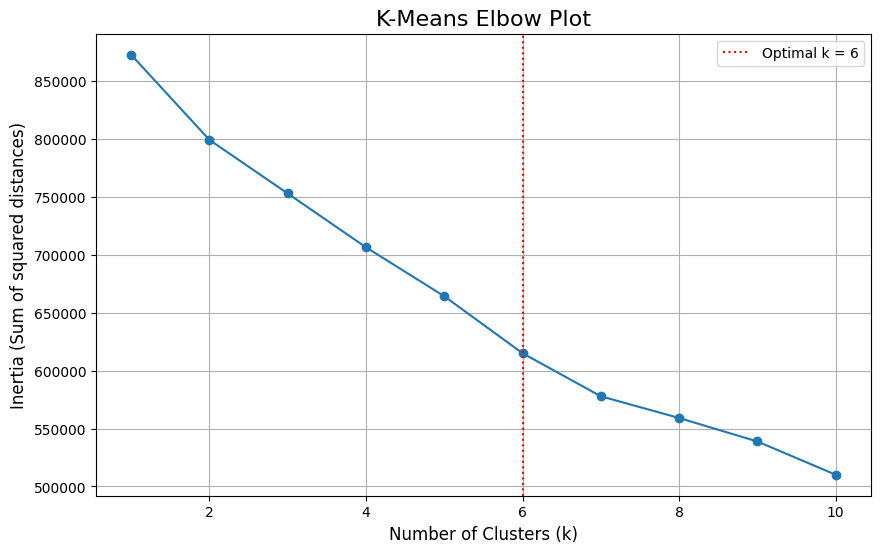

In [41]:
print("\n--- 3. K-Means Clustering ---")

print("Calculating K-Means elbow plot...")
inertia = []
k_range = range(1, 11) 
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(df_pca_analysis)
    inertia.append(kmeans.inertia_)

# Find the elbow with KneeLocator
kneedle_kmeans = KneeLocator(k_range, inertia, curve='convex', direction='decreasing')
k_optimal = kneedle_kmeans.knee

print(f"Optimal K found at k = {k_optimal}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.axvline(x=k_optimal, color='r', linestyle=':', label=f'Optimal k = {k_optimal}')
plt.title('K-Means Elbow Plot', fontsize=16)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Sum of squared distances)', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()


Running K-Means with k=6...
Plotting K-Means cluster results...


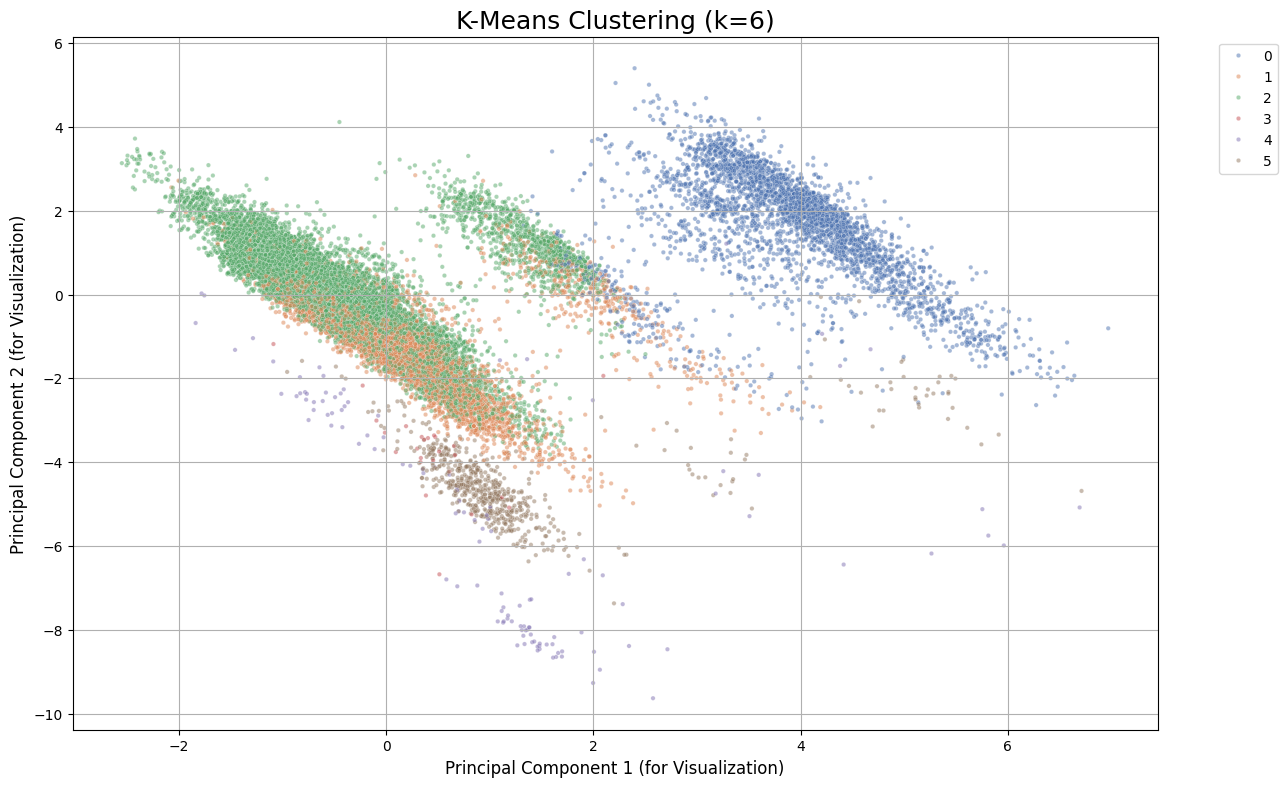

In [42]:
print(f"Running K-Means with k={k_optimal}...")
kmeans = KMeans(n_clusters=k_optimal, n_init=10, random_state=42)
km_labels = kmeans.fit_predict(df_pca_analysis)

df_pca_visual['km_cluster'] = km_labels
print("Plotting K-Means cluster results...")
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_pca_visual, 
    x='PCA1', y='PCA2', hue='km_cluster', 
    palette='deep', s=10, alpha=0.5
)
plt.title(f'K-Means Clustering (k={k_optimal})', fontsize=18)
plt.xlabel('Principal Component 1 (for Visualization)', fontsize=12)
plt.ylabel('Principal Component 2 (for Visualization)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Evaluation of Clusters

### SSE

In [60]:
sse = kmeans.inertia_
print(f"K-Means (k=6) SSE (Inertia): {sse}")

K-Means (k=6) SSE (Inertia): 615067.2469509087


### Cluster Cohesion

In [61]:
def cluster_cohesion(X, labels):
    """Average intra-cluster distance"""
    unique_labels = [l for l in np.unique(labels) if l != -1]
    dists = pairwise_distances(X)
    cohesion = np.mean([
        np.mean(dists[np.ix_(labels == l, labels == l)])
        for l in unique_labels
    ])
    return cohesion

In [ ]:
labels_kmean = kmeans.labels_
labels_hier = hier.labels_

print(f"K-Means (k=6) Cluster Cohesion: {cluster_cohesion(df_pca_analysis, labels_kmean)}")
print(f"Hierarchical Cluster Cohesion: {cluster_cohesion(df_pca_analysis, labels_hier)}")
print(f"DBSCAN-1 Cluster Cohesion: {cluster_cohesion(df_pca_analysis, db_labels_1)}")


K-Means (k=6) Cluster Cohesion: 5.66912571791989
Hierarchical Cluster Cohesion: 5.427752983663147
DBSCAN-1 Cluster Cohesion: 5.182755464781574
DBSCAN-2 Cluster Cohesion: 5.182755464781574


In [63]:
print(f"DBSCAN-2 Cluster Cohesion: {cluster_cohesion(df_pca_analysis, db_labels_2)}")

DBSCAN-2 Cluster Cohesion: 6.737237501123913


### Cluster Separation

In [64]:
def cluster_separation(X, labels):
    """Average inter-cluster distance"""
    unique_labels = [l for l in np.unique(labels) if l != -1]
    centroids = np.array([X[labels == l].mean(axis=0) for l in unique_labels])
    inter_dists = pairwise_distances(centroids)
    separation = np.mean(inter_dists[np.triu_indices_from(inter_dists, 1)])
    return separation

In [66]:
print(f"K-Means (k=6) Cluster Separation: {cluster_separation(df_pca_analysis, labels_kmean)}")
print(f"Hierarchical Cluster Separation: {cluster_separation(df_pca_analysis, labels_hier)}")
print(f"DBSCAN-1 Cluster Separation: {cluster_separation(df_pca_analysis, db_labels_1)}")
print(f"DBSCAN-2 Cluster Separation: {cluster_separation(df_pca_analysis, db_labels_2)}")


K-Means (k=6) Cluster Separation: 22.48129086997618
Hierarchical Cluster Separation: 4.108892570887099
DBSCAN-1 Cluster Separation: 16.315580556969277
DBSCAN-2 Cluster Separation: 19.67313295105854


### Hopkins Statistic

In [56]:
def hopkins_statistic(X):
    if not isinstance(X, np.ndarray):
        X = X.values
        
    n_rows, n_cols = X.shape
    m = int(0.1 * n_rows)
    if m <= 0:
        m = 1
        
    X_sample_indices = random.sample(range(n_rows), m)
    X_sample = X[X_sample_indices]
    
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    u_d, _ = nbrs.kneighbors(X_sample, n_neighbors=2)
    u_d = u_d[:, 1] 
    X_fake = np.random.uniform(X.min(axis=0), X.max(axis=0), (m, n_cols))
    v_d, _ = nbrs.kneighbors(X_fake, n_neighbors=1)
    v_d = v_d[:, 0]
    H = np.sum(v_d) / (np.sum(u_d) + np.sum(v_d))
    return H

hopkins_stat = hopkins_statistic(df_pca_analysis)
print(f"Hopkins Statistic: {hopkins_stat:.4f}")
print("(Close to 1.0 is good, ~0.5 is random)")

Hopkins Statistic: 0.9682
(Close to 1.0 is good, ~0.5 is random)


In [43]:
k_silhouette = silhouette_score(df_pca_analysis, km_labels)
hier_silhouette = silhouette_score(df_pca_analysis, labels_hier)
print(f"K-Means Silhouette Score: {k_silhouette:.3f}")
print(f"Hierarchical Silhouette Score: {hier_silhouette:.3f}")

K-Means Silhouette Score: 0.146
Hierarchical Silhouette Score: 0.065


In [72]:
coordinates = df[['latitude', 'longitude']]

In [73]:
results_df = df_cluster.copy()

In [74]:
results_df = results_df.join(coordinates)

In [75]:
results_df.columns

Index(['district', 'crash_occurred_on', 'type_of_roadway', 'road_surface',
       'injury', 'fatality', 'hit_and_run', 'pedestrian_involved',
       'train_involved', 'intersection', 'vehicle_alignment',
       'relation_to_roadway', 'manner_of_collision', 'primary_factor',
       'secondary_factor', 'vehicle_bin', 'is_weekend', 'season',
       'light_group', 'weather_group', 'db_cluster_1', 'db_cluster_2',
       'latitude', 'longitude'],
      dtype='object')

In [76]:
np.unique(db_labels_1)

array([-1,  0,  1,  2,  3])

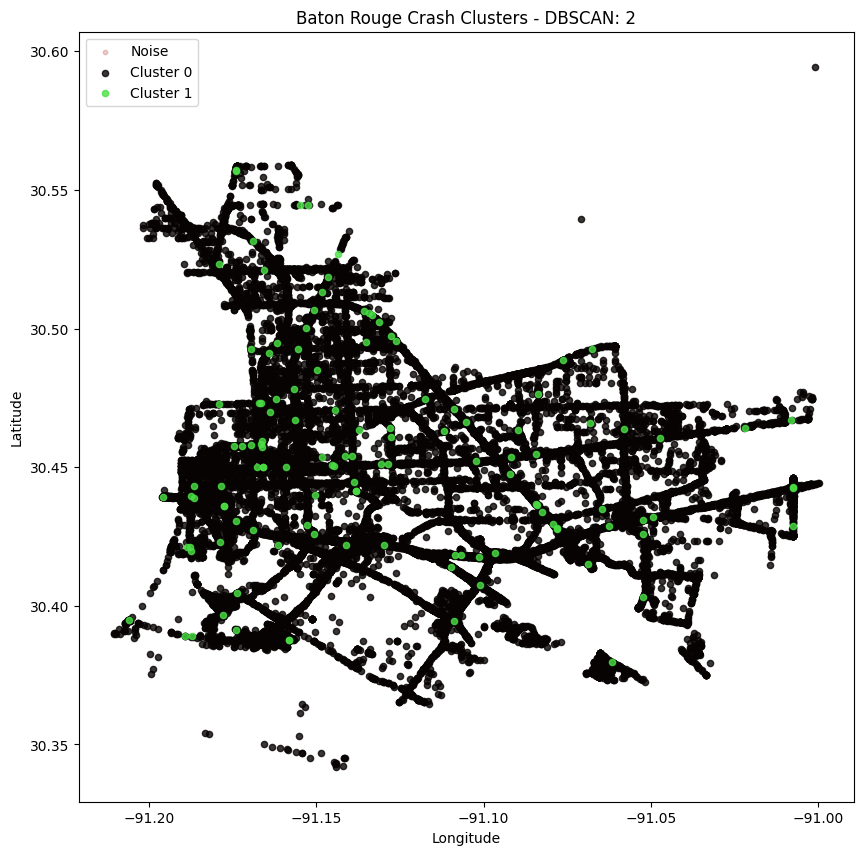

In [102]:
plt.figure(figsize=(10, 10))

noise_data = results_df[results_df['db_cluster_2'] == -1]
plt.scatter(noise_data['longitude'], noise_data['latitude'], 
            c="#A00A0A", s=10, alpha=0.2, label='Noise')

unique_clusters = [c for c in sorted(results_df['db_cluster_2'].unique()) if c != -1]
rainbow = ["#080303", "#4ae045", "#e7e01b", "#935CAC"]

for i, cluster_id in enumerate(unique_clusters):
    cluster_data = results_df[results_df['db_cluster_2'] == cluster_id]
    color = rainbow[i % len(rainbow)] 
    
    plt.scatter(cluster_data['longitude'], cluster_data['latitude'], 
                c=color, s=20, alpha=0.8, label=f'Cluster {cluster_id}')

plt.title("Baton Rouge Crash Clusters - DBSCAN: 2")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(False) 
plt.show()

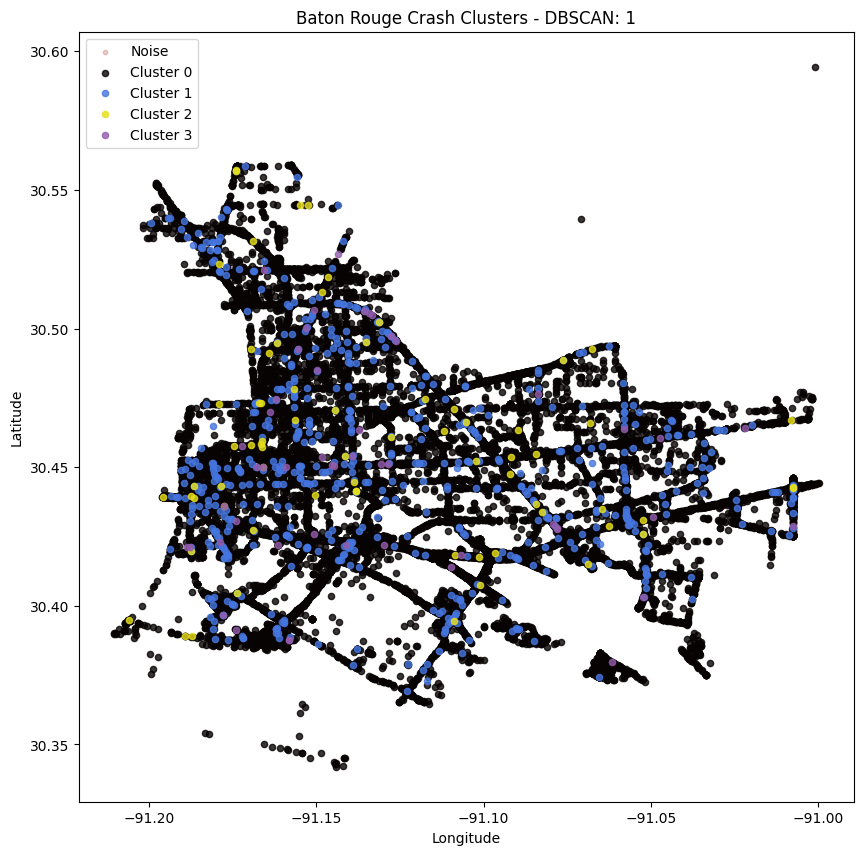

In [99]:
plt.figure(figsize=(10, 10))

noise_data = results_df[results_df['db_cluster_1'] == -1]
plt.scatter(noise_data['longitude'], noise_data['latitude'], 
            c="#A00A0A", s=10, alpha=0.2, label='Noise')

unique_clusters = [c for c in sorted(results_df['db_cluster_1'].unique()) if c != -1]
rainbow = ["#080303", "#4576e0", "#e7e01b", "#935CAC"]

for i, cluster_id in enumerate(unique_clusters):
    cluster_data = results_df[results_df['db_cluster_1'] == cluster_id]
    color = rainbow[i % len(rainbow)] 
    
    plt.scatter(cluster_data['longitude'], cluster_data['latitude'], 
                c=color, s=20, alpha=0.8, label=f'Cluster {cluster_id}')

plt.title("Baton Rouge Crash Clusters - DBSCAN: 1")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(False) 
plt.show()